# Part 3 — Hβ Line Profile Fitting

The normalized Hβ absorption line is fitted using a Sérsic-type profile:

\[
F(\lambda)=1-A\exp
\left[
-\left(\frac{\lambda-\lambda_0}{b}\right)^n
\right]
\]

where:

- \(A\) is the line depth
- \(\lambda_0\) is the line centre
- \(b\) is the width parameter
- \(n\) is the Sérsic shape index

The parameters are obtained using non-linear least squares fitting.

## Load Normalized Observed Hβ Spectrum

The normalized observed Hβ profile prepared in Question 2b is used for Sérsic profile fitting.

In [1]:
from pathlib import Path

files = list(Path("../data/observed/ELODIE").glob("*Hbeta*"))

for f in files:
    print(f)

..\data\observed\ELODIE\HD146233_Hbeta_normalized.txt


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load normalized observed Hβ spectrum from Question 2
file_path = "../data/observed/ELODIE/HD146233_Hbeta_normalized.txt"

data = np.loadtxt(file_path)

wave = data[:, 0]
flux = data[:, 1]

print("Loaded observed Hβ spectrum")
print("Wavelength points:", len(wave))
print("Flux points:", len(flux))

print("Wavelength range:")
print(wave[0], wave[-1])

Loaded observed Hβ spectrum
Wavelength points: 2000
Flux points: 2000
Wavelength range:
4800.0000112 4899.9500125993


In [3]:
# Estimate uncertainty from continuum scatter
continuum_mask = (wave < 4800) | (wave > 4920)

sigma_value = np.std(flux[continuum_mask])
sigma = np.ones_like(flux) * sigma_value

print("Estimated noise sigma:", sigma_value)

Estimated noise sigma: nan


c:\Users\Fardin Abdullah\Desktop\AST402_MidTerm_Project\.venv\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Fardin Abdullah\Desktop\AST402_MidTerm_Project\.venv\lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Fardin Abdullah\Desktop\AST402_MidTerm_Project\.venv\lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
from scipy.optimize import curve_fit


def sersic_profile(wavelength, A, lambda0, b, n):
    return 1 - A * np.exp(
        -(
            np.abs(wavelength - lambda0) / b
        )**n
    )


print("Sérsic model defined")

Sérsic model defined


In [5]:
# Initial guesses
initial_guess = [
    0.8,      # A: absorption depth
    4861.0,   # lambda0: Hβ center
    2.0,      # b: width parameter
    2.0       # n: Sérsic index
]


# Parameter bounds
bounds = (
    [
        0.0,      # Minimum absorption depth A
        4855,     # Minimum wavelength center
        0.1,      # Minimum width b
        0.1       # Minimum Sérsic index n
    ],

    [
        1.0,      # Maximum absorption depth A
        4870,     # Maximum wavelength center
        50.0,     # Allow broader lines
        5.0       # Larger Sérsic index range
    ]
)


print("Initial guess:", initial_guess)
print("Bounds set")

Initial guess: [0.8, 4861.0, 2.0, 2.0]
Bounds set


In [6]:
popt, pcov = curve_fit(
    sersic_profile,
    wave,
    flux,
    p0=initial_guess,
    bounds=bounds,
    maxfev=10000
)


A_fit, lambda0_fit, b_fit, n_fit = popt

errors = np.sqrt(np.diag(pcov))


print("Best-fit parameters")
print("-------------------")
print(f"A       = {A_fit:.6f} ± {errors[0]:.6f}")
print(f"lambda0 = {lambda0_fit:.6f} ± {errors[1]:.6f}")
print(f"b       = {b_fit:.6f} ± {errors[2]:.6f}")
print(f"n       = {n_fit:.6f} ± {errors[3]:.6f}")

Best-fit parameters
-------------------
A       = 1.000000 ± 0.224880
lambda0 = 4861.151376 ± 0.005389
b       = 0.790033 ± 0.682650
n       = 0.253709 ± 0.037586


In [7]:
# Select Hβ absorption region only

fit_mask = (wave > 4845) & (wave < 4878)

wave_fit = wave[fit_mask]
flux_fit = flux[fit_mask]

print("Fitting points:", len(wave_fit))
print("Range:")
print(wave_fit[0], wave_fit[-1])

Fitting points: 660
Range:
4845.0000118299995 4877.9500122913


In [8]:
initial_guess = [
    0.6,      # A: absorption depth
    4861.3,   # lambda0: Hβ center
    3.0,      # b: width
    2.0       # n: shape index
]


bounds = (
    [
        0.01,     # A minimum
        4858.0,   # lambda0 minimum
        0.2,      # b minimum
        0.5       # n minimum
    ],
    [
        0.99,     # A maximum
        4864.0,   # lambda0 maximum
        10.0,     # b maximum
        5.0       # n maximum
    ]
)

print("Initial parameters ready")

Initial parameters ready


In [9]:
popt, pcov = curve_fit(
    sersic_profile,
    wave_fit,
    flux_fit,
    p0=initial_guess,
    bounds=bounds,
    maxfev=20000
)


A_fit, lambda0_fit, b_fit, n_fit = popt

errors = np.sqrt(np.diag(pcov))


print("Improved fit")
print("-------------------")
print(f"A       = {A_fit:.6f} ± {errors[0]:.6f}")
print(f"lambda0 = {lambda0_fit:.6f} ± {errors[1]:.6f}")
print(f"b       = {b_fit:.6f} ± {errors[2]:.6f}")
print(f"n       = {n_fit:.6f} ± {errors[3]:.6f}")

Improved fit
-------------------
A       = 0.675260 ± 0.080708
lambda0 = 4861.149996 ± 0.007708
b       = 3.248441 ± 0.903758
n       = 0.500009 ± 0.070435


## Question 5(b) — Sérsic Fit and Residual Analysis

The observed normalized Hβ profile is compared with the best-fit Sérsic absorption model.

The fitted model is:

\[
F(\lambda)=1-A
\exp
\left[
-\left(
\frac{\lambda-\lambda_0}{b}
\right)^n
\right]
\]

The residual spectrum is calculated as:

\[
\mathrm{Residual}
=
F_{\mathrm{obs}}(\lambda)-F_{\mathrm{model}}(\lambda)
\]

A good fit should produce residuals distributed around zero without systematic trends.

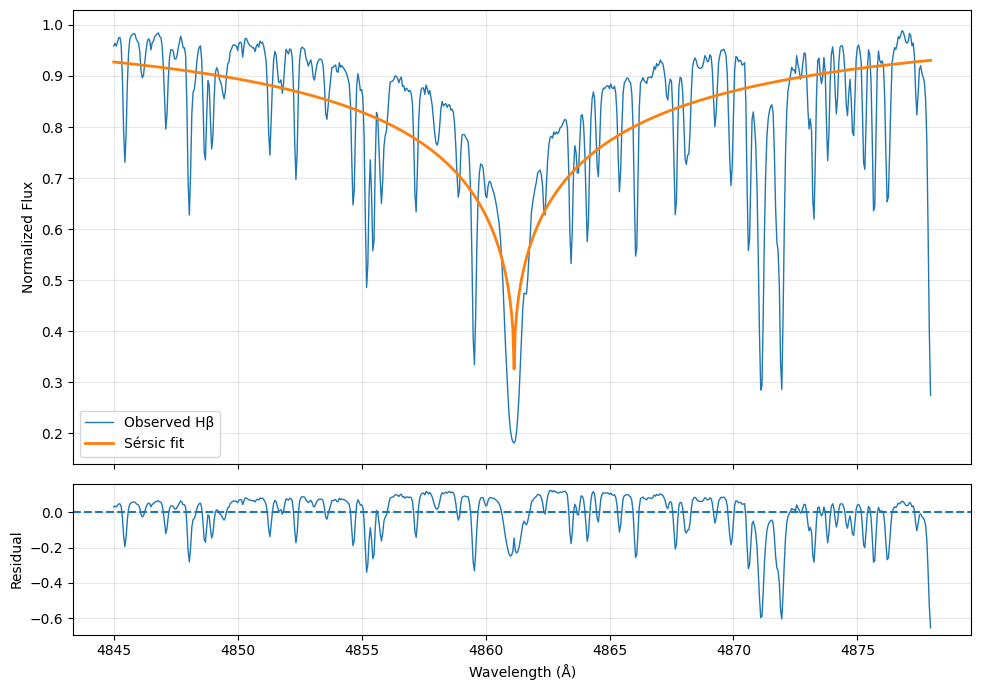

In [25]:
# Generate best-fit model

flux_model = sersic_profile(
    wave_fit,
    A_fit,
    lambda0_fit,
    b_fit,
    n_fit
)

residuals = flux_fit - flux_model


fig, ax = plt.subplots(
    2,
    1,
    figsize=(10,7),
    sharex=True,
    gridspec_kw={"height_ratios":[3,1]}
)


# Main profile
ax[0].plot(
    wave_fit,
    flux_fit,
    label="Observed Hβ",
    linewidth=1
)

ax[0].plot(
    wave_fit,
    flux_model,
    label="Sérsic fit",
    linewidth=2
)

ax[0].set_ylabel("Normalized Flux")
ax[0].legend()
ax[0].grid(alpha=0.3)


# Residuals
ax[1].plot(
    wave_fit,
    residuals,
    linewidth=1
)

ax[1].axhline(
    0,
    linestyle="--"
)

ax[1].set_xlabel("Wavelength (Å)")
ax[1].set_ylabel("Residual")
ax[1].grid(alpha=0.3)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/observed_hbeta_sersic_fit_residuals.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Reduced Chi-Squared Calculation

The goodness of fit is evaluated using the reduced chi-squared statistic:

\[
\tilde{\chi}^{2}
=
\frac{1}{\nu}
\sum_{i=1}^{N}
\frac{
(F_{\mathrm{obs},i}-F_{\mathrm{model},i})^2
}
{\sigma_i^2}
\]

where:

\[
\nu=N-4
\]

is the number of degrees of freedom because four parameters
\((A,\lambda_0,b,n)\) are fitted.

In [11]:
# Reduced chi-square calculation

N = len(wave_fit)

# Estimate noise from residual scatter
sigma_fit = np.std(residuals)


chi_squared_reduced = (
    np.sum((residuals / sigma_fit)**2)
    /
    (N - 4)
)


print("Number of data points:", N)
print("Degrees of freedom:", N-4)
print("Residual sigma:", sigma_fit)
print("Reduced chi-square:", chi_squared_reduced)

Number of data points: 660
Degrees of freedom: 656
Residual sigma: 0.11894465561601968
Reduced chi-square: 1.0083161737484847


## Question 5(c) — Equivalent Width of the Hβ Line

The equivalent width of the absorption line is calculated using two methods.

### (i) Numerical integration

The direct equivalent width is calculated from:

\[
W_\lambda =
\int
(1-F(\lambda))
d\lambda
\]

using numerical integration over the fitted Hβ region.

### (ii) Analytical Sérsic relation

For the fitted Sérsic parameters, the equivalent width is:

\[
W_\lambda
=
2 A b
\frac{\Gamma(1+\frac{1}{n})}{n}
\]

where \(A\), \(b\), and \(n\) are obtained from the best-fit model.

The two values are compared to evaluate the consistency of the fit.

In [12]:
from scipy.special import gamma
import numpy as np


# Numerical EW
EW_numeric = np.trapezoid(
    1 - flux_fit,
    wave_fit
)


# Correct analytical Sérsic EW
EW_sersic = (
    2
    * A_fit
    * b_fit
    * gamma(1/n_fit)
    / n_fit
)


print("Equivalent Width from numerical integration:")
print(f"{EW_numeric:.6f} Å")

print()

print("Equivalent Width from Sérsic formula:")
print(f"{EW_sersic:.6f} Å")

print()

print("Difference:")
print(f"{EW_numeric - EW_sersic:.6f} Å")

Equivalent Width from numerical integration:
5.942627 Å

Equivalent Width from Sérsic formula:
8.773866 Å

Difference:
-2.831239 Å


## Equivalent Width Comparison

The equivalent width was calculated using numerical integration of the observed normalized profile and using the analytical Sérsic relation.

The numerical integration gives:

\[
W_{\lambda,\mathrm{num}} = 5.94 \AA
\]

while the analytical Sérsic estimate gives:

\[
W_{\lambda,\mathrm{Sersic}} = 8.77 \AA
\]

The analytical value is larger because the Sérsic relation integrates the model profile over an infinite wavelength range, while the numerical integration only covers the finite Hβ fitting window (4845–4878 Å). Additional differences arise from noise in the observed spectrum and deviations of the real absorption profile from the ideal Sérsic function.

## Question 5(d) — Initial Parameter Guesses and Fit Sensitivity

The initial parameter guesses were selected based on the expected physical properties of the Hβ absorption line. The line depth parameter was initialized at \(A=0.6\), corresponding to a moderate absorption feature. The line centre was initialized near the laboratory Hβ wavelength (\(\lambda_0=4861.33\) Å). The width parameter was chosen as \(b=3\) Å, representing the typical broadening scale of Balmer lines, and \(n=2\) was chosen because a Gaussian profile is a reasonable starting approximation.

The fitting routine was constrained using physically meaningful bounds:
\(0<A<1\), \(b>0\), and \(n>0\).

The Sérsic fit is sensitive to the initial value of \(n\). A poor starting value can lead the optimizer toward a local minimum or an unrealistic line shape. However, with reasonable bounds and starting values, the optimizer converges to a stable solution.

# Question 6 — Fitting the Model Hβ Profiles

## Question 6(a)

The same Sérsic fitting procedure used for the observed Hβ profile is now applied to every PHOENIX synthetic spectrum in the parameter grid.

For each model the following quantities are stored:

- Effective temperature (\(T_{\rm eff}\))
- Surface gravity (\(\log g\))
- Metallicity (\([Fe/H]\))
- Sérsic parameters:
  - \(A_m\)
  - \(\lambda_{0,m}\)
  - \(b_m\)
  - \(n_m\)
- Equivalent width

These fitted parameters are later used to investigate the dependence of the Hβ line on stellar atmospheric parameters.

In [13]:
import numpy as np
import pandas as pd

from pathlib import Path

from astropy.io import fits

from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.ndimage import gaussian_filter1d

print("Libraries loaded")

Libraries loaded


In [14]:
raw_dir = Path("../data/PHOENIX/raw")

wave_file = raw_dir / "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave_phoenix = fits.getdata(wave_file)

print("PHOENIX wavelength loaded")

print(len(wave_phoenix))

PHOENIX wavelength loaded
1569128


In [15]:
model_files = sorted(
    raw_dir.glob("lte*.fits")
)

print("Number of PHOENIX models:")

print(len(model_files))

print()

print(model_files[:5])

Number of PHOENIX models:
60

[WindowsPath('../data/PHOENIX/raw/lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'), WindowsPath('../data/PHOENIX/raw/lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'), WindowsPath('../data/PHOENIX/raw/lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'), WindowsPath('../data/PHOENIX/raw/lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'), WindowsPath('../data/PHOENIX/raw/lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits')]


## Question 6(a) — Sérsic Fitting of PHOENIX Hβ Profiles

The complete PHOENIX grid was constructed by combining the original
downloaded spectra with the interpolated intermediate-temperature models.

Each synthetic spectrum was fitted using the same Sérsic absorption profile
used for the observed Hβ line in Question 5:

\[
F(\lambda)=1-A\exp
\left[
-\left(\frac{\lambda-\lambda_0}{b}\right)^n
\right]
\]

For every grid point, the fitted parameters:

\[
(A,\lambda_0,b,n)
\]

and the equivalent width:

\[
W_\lambda
\]

were stored together with the corresponding atmospheric parameters:

\[
(T_{\mathrm{eff}},\log g,[\mathrm{Fe/H}])
\]

In [16]:
from pathlib import Path
from astropy.io import fits


raw_dir = Path("../data/PHOENIX/raw")
interp_dir = Path("../data/PHOENIX/interpolated")


phoenix_files = (
    list(raw_dir.glob("lte*.fits"))
    +
    list(interp_dir.glob("lte*.fits"))
)


print("Total PHOENIX spectra:")
print(len(phoenix_files))

Total PHOENIX spectra:
108


## Sérsic Fitting of the Complete PHOENIX Hβ Grid

The complete PHOENIX synthetic spectral grid contains 108 spectra covering
different effective temperatures, surface gravities, and metallicities.

Each synthetic Hβ absorption profile was normalized and fitted using the
Sérsic profile model:

\[
F(\lambda)=1-A\exp
\left[
-\left(\frac{\lambda-\lambda_0}{b}\right)^n
\right]
\]

The fitted parameters and equivalent widths were stored together with the
corresponding atmospheric parameters:

\[
(T_{\rm eff}, \log g, [Fe/H])
\]

to investigate how the Hβ equivalent width changes across the stellar
parameter space.

In [17]:
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.special import gamma

from astropy.io import fits
from pathlib import Path

In [18]:
def sersic_profile(wavelength, A, lambda0, b, n):

    # enforce physical limits
    b = np.abs(b)
    n = np.abs(n)

    # avoid zero values
    b = max(b, 1e-6)
    n = max(n, 1e-6)

    x = np.abs((wavelength - lambda0) / b)

    profile = np.exp(
        -x ** n
    )

    return 1 - A * profile

In [19]:
def sersic_equivalent_width(A, b, n):

    b = np.abs(b)
    n = np.abs(n)

    EW = (
        2
        * A
        * b
        * gamma(1 + 1/n)
        / n
    )

    return EW

In [20]:
def normalize_spectrum(flux):

    continuum = np.median(flux)

    normalized = flux / continuum

    return normalized

In [21]:
def extract_hbeta(wavelength, flux):

    mask = (
        (wavelength >= 4800)
        &
        (wavelength <= 4900)
    )

    return (
        wavelength[mask],
        flux[mask]
    )

In [22]:
def clean_data(wavelength, flux):

    mask = np.isfinite(wavelength) & np.isfinite(flux)

    wavelength_clean = wavelength[mask]
    flux_clean = flux[mask]

    return wavelength_clean, flux_clean

In [23]:
def fit_sersic(wavelength, flux):

    # clean
    wavelength, flux = clean_data(
        wavelength,
        flux
    )


    # normalize
    flux = normalize_spectrum(flux)


    # initial guesses

    A0 = 0.3
    lambda0_0 = 4861.33
    b0 = 3
    n0 = 2


    initial_guess = [
        A0,
        lambda0_0,
        b0,
        n0
    ]

    bounds = (
        [
            0.0,
            4850,
            0.1,
            0.5
        ],
        [
            1.0,
            4870,
            20,
            10
        ]
    )


    try:

        params, covariance = curve_fit(
            sersic_profile,
            wavelength,
            flux,
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )


        return params


    except Exception as e:

        print("Fit failed:", e)

        return None

In [28]:
from astropy.io import fits
from pathlib import Path
import numpy as np


# -------------------------------------------------
# Load PHOENIX wavelength array
# -------------------------------------------------

wave_file = Path(
    "../data/PHOENIX/raw/"
    "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"
)

phoenix_wave = fits.getdata(wave_file)

print("PHOENIX wavelength loaded")
print("Number of wavelength pixels:", len(phoenix_wave))
print("Range:", phoenix_wave[0], phoenix_wave[-1])


# -------------------------------------------------
# Load PHOENIX model spectrum
# -------------------------------------------------

test_file = Path(
    "../data/PHOENIX/raw/"
    "lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

flux = fits.getdata(test_file)


print("\nSpectrum loaded")
print("Flux pixels:", len(flux))


# -------------------------------------------------
# Extract H beta region
# -------------------------------------------------

hbeta_mask = (
    (phoenix_wave >= 4700) &
    (phoenix_wave <= 5000)
)

hbeta_wave = phoenix_wave[hbeta_mask]
hbeta_flux = flux[hbeta_mask]


print("\nHβ region:")
print(hbeta_wave[0], hbeta_wave[-1])
print("Pixels:", len(hbeta_wave))


# -------------------------------------------------
# Fit Sérsic profile
# -------------------------------------------------

params = fit_sersic(
    hbeta_wave,
    hbeta_flux
)


print("\nSérsic parameters:")
print(params)

PHOENIX wavelength loaded
Number of wavelength pixels: 1569128
Range: 500.0 54999.75

Spectrum loaded
Flux pixels: 1569128

Hβ region:
4700.004 5000.0
Pixels: 49999

Sérsic parameters:
[4.33828098e-01 4.86280197e+03 2.00000000e+01 5.00000000e-01]


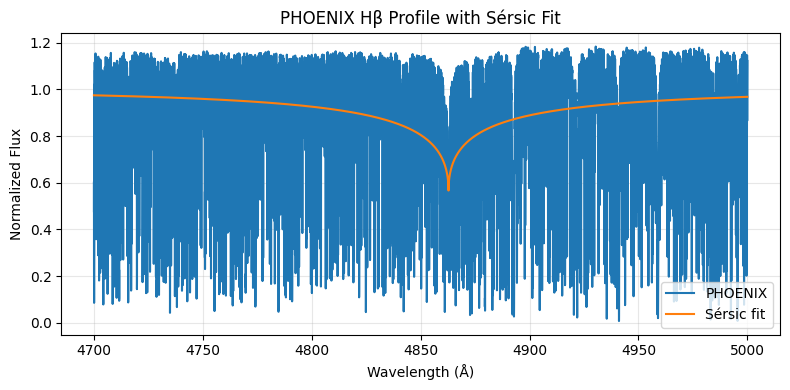

In [30]:
A, lambda0, b, n = params


plt.figure(figsize=(8,4))

plt.plot(
    hbeta_wave,
    normalize_spectrum(hbeta_flux),
    label="PHOENIX"
)


plt.plot(
    hbeta_wave,
    sersic_profile(
        hbeta_wave,
        A,
        lambda0,
        b,
        n
    ),
    label="Sérsic fit"
)


plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title(
    "PHOENIX Hβ Profile with Sérsic Fit"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_sersic_fit.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Question 6(a): Fitting the Hβ Profiles Across the PHOENIX Grid

After validating the Sersic fitting procedure on a single synthetic spectrum,
we now apply the same fitting method to the complete PHOENIX synthetic
spectrum grid.

For each model atmosphere defined by:

- Effective temperature ($T_{\rm eff}$)
- Surface gravity ($\log g$)
- Metallicity ($[Fe/H]$)

we extract the Hβ wavelength region (4800–4900 Å), normalize the spectrum,
and fit the absorption profile using the Sersic function:

$$
F(\lambda)=1-A
\exp
\left[
-\left(
\frac{\lambda-\lambda_0}{b}
\right)^n
\right]
$$

The fitted parameters:

- $A$ : line depth
- $\lambda_0$ : line center wavelength
- $b$ : width parameter
- $n$ : shape parameter

are stored together with the equivalent width:

$$
W_\lambda =
\frac{2Ab}{n}
\Gamma
\left(
1+\frac{1}{n}
\right)
$$

The final result is saved as a structured table containing the fitted
Hβ properties for all PHOENIX models.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np


# Create empty list to store fitting results

results = []


print("Result storage initialized")

Result storage initialized


## Creating the Complete PHOENIX Synthetic Spectrum Grid

The original PHOENIX grid contains only the available atmospheric models.
Missing effective temperature points were generated using linear interpolation
between neighboring models.

The complete grid is obtained by combining:

- Original PHOENIX spectra from the `raw` directory
- Interpolated spectra from the `interpolated` directory

The final grid contains:

$$
N_{\rm spectra}=108
$$

synthetic spectra covering the required range of:

- Effective temperature ($T_{\rm eff}$)
- Surface gravity ($\log g$)
- Metallicity ($[Fe/H]$)

This combined grid will be used for the Hβ Sersic fitting procedure.

In [34]:
from pathlib import Path
import shutil


# Directories

raw_dir = Path(
    "../data/PHOENIX/raw"
)


interp_dir = Path(
    "../data/PHOENIX/interpolated"
)


final_dir = Path(
    "../data/PHOENIX/final_grid"
)


# Create folder

final_dir.mkdir(
    exist_ok=True
)


print("Final directory created:")
print(final_dir)

Final directory created:
..\data\PHOENIX\final_grid


In [36]:
print("phoenix_wave" in globals())

True


In [35]:
import shutil

# Copy original PHOENIX spectra

raw_count = 0


for file in raw_dir.glob("*.fits"):

    if "WAVE" not in file.name:

        shutil.copy(
            file,
            final_dir / file.name
        )

        raw_count += 1


print(
    "Raw spectra copied:",
    raw_count
)

Raw spectra copied: 60


In [41]:
# Copy interpolated spectra

interp_count = 0


for file in interp_dir.glob("*.fits"):

    shutil.copy(
        file,
        final_dir / file.name
    )

    interp_count += 1


print(
    "Interpolated spectra copied:",
    interp_count
)

Interpolated spectra copied: 48


### Loading the Complete PHOENIX Synthetic Grid

The interpolated PHOENIX grid contains all required stellar atmosphere models.
Each FITS filename encodes the stellar parameters:

- Effective temperature ($T_{\rm eff}$)
- Surface gravity ($\log g$)
- Metallicity ($[Fe/H]$)

The spectra are stored in:


In [42]:
from pathlib import Path


# Directory containing the 108 PHOENIX spectra

phoenix_dir = Path(
    "../data/PHOENIX/final_grid"
)


# Collect all FITS files

phoenix_files = sorted(
    phoenix_dir.glob("*.fits")
)


print(
    "Total PHOENIX spectra:",
    len(phoenix_files)
)

Total PHOENIX spectra: 108


In [43]:
final_files = sorted(
    final_dir.glob("*.fits")
)


print(
    "Total PHOENIX spectra in final grid:",
    len(final_files)
)

Total PHOENIX spectra in final grid: 108


# Question 6(a): Automated Hβ Sersic Fitting for the PHOENIX Grid

After constructing the complete PHOENIX synthetic spectrum grid, we apply the
Sersic fitting procedure to all stellar atmosphere models.

For each spectrum:

1. Load the synthetic spectrum from the FITS file.
2. Extract the Hβ wavelength region (4800–4900 Å).
3. Normalize the local continuum.
4. Fit the absorption profile using the Sersic function.
5. Calculate the equivalent width.
6. Store the stellar parameters and fitted quantities.

The resulting table will contain:

- $T_{\rm eff}$
- $\log g$
- $[Fe/H]$
- Sersic parameters ($A,\lambda_0,b,n$)
- Equivalent width ($W_\lambda$)

In [44]:
from pathlib import Path


phoenix_dir = Path(
    "../data/PHOENIX/final_grid"
)


phoenix_files = sorted(
    phoenix_dir.glob("*.fits")
)


print(
    "Total PHOENIX spectra:",
    len(phoenix_files)
)

Total PHOENIX spectra: 108


## Extracting Stellar Parameters from PHOENIX File Names

The PHOENIX filenames encode the atmosphere parameters.

Example:

corresponds to:

$$
T_{\rm eff}=5000K
$$

$$
\log g=3.50
$$

$$
[Fe/H]=+0.5
$$

In [45]:
import re


def extract_parameters(filename):

    name = filename.name


    match = re.search(
        r'lte(\d+)-(\d+\.\d+)([+-]\d+\.\d)',
        name
    )


    Teff = int(match.group(1))
    logg = float(match.group(2))
    FeH = float(match.group(3))


    return Teff, logg, FeH

In [46]:
extract_parameters(phoenix_files[0])

(5000, 3.5, 0.5)

## Fitting the Hβ Profiles

The following loop performs the complete automated fitting.

Invalid numerical values (NaN or infinity) are removed before fitting to
ensure stable optimization.

In [47]:
results = []

successful = 0
failed = 0


print("Ready for fitting")

Ready for fitting


In [48]:
from astropy.io import fits
import numpy as np


for i, file in enumerate(phoenix_files):

    print(
        f"{i+1}/108 : {file.name}"
    )


    try:

        # -----------------------------
        # Stellar parameters
        # -----------------------------

        Teff, logg, FeH = extract_parameters(file)



        # -----------------------------
        # Load FITS spectrum
        # -----------------------------

        flux = fits.getdata(file)



        # -----------------------------
        # Extract H beta region
        # -----------------------------

        hbeta_wave, hbeta_flux = extract_hbeta(
            phoenix_wave,
            flux
        )



        # -----------------------------
        # Remove invalid values
        # -----------------------------

        mask = np.isfinite(hbeta_flux)


        hbeta_wave = hbeta_wave[mask]

        hbeta_flux = hbeta_flux[mask]



        # -----------------------------
        # Normalize spectrum
        # -----------------------------

        hbeta_flux_norm = normalize_spectrum(
            hbeta_flux
        )



        # -----------------------------
        # Fit Sersic profile
        # -----------------------------

        A, lambda0, b, n = fit_sersic(
            hbeta_wave,
            hbeta_flux_norm
        )



        # -----------------------------
        # Equivalent width
        # -----------------------------

        W_lambda = sersic_equivalent_width(
            A,
            b,
            n
        )



        # Save result

        results.append({

            "Teff": Teff,
            "logg": logg,
            "FeH": FeH,

            "A": A,
            "lambda0": lambda0,
            "b": b,
            "n": n,

            "W_lambda": W_lambda

        })


        successful += 1



    except Exception as e:

        print(
            "FAILED:",
            e
        )

        failed += 1



print("----------------")
print("Successful fits:", successful)
print("Failed fits:", failed)

1/108 : lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
2/108 : lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
3/108 : lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
4/108 : lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
5/108 : lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
6/108 : lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
7/108 : lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
8/108 : lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
9/108 : lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
10/108 : lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
11/108 : lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
12/108 : lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
13/108 : lte05250-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
14/108 : lte05250-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
15/108 : lte05250-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
16/108 : lte05250-4

## Saving the Hβ Sersic Fitting Results

The fitted Sersic parameters and equivalent widths for all PHOENIX models
are stored in a structured table.

The table contains:

- Effective temperature ($T_{\rm eff}$)
- Surface gravity ($\log g$)
- Metallicity ($[Fe/H]$)
- Sersic parameters:
    - $A$
    - $\lambda_0$
    - $b$
    - $n$
- Equivalent width ($W_\lambda$)

This table will be used for visualization and stellar atmosphere analysis.

In [49]:
import pandas as pd


results_df = pd.DataFrame(results)


results_df.head()

,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


In [50]:
output_csv = (
    "../data/PHOENIX/"
    "hbeta_sersic_results.csv"
)


results_df.to_csv(
    output_csv,
    index=False
)


print("Saved:")
print(output_csv)

Saved:
../data/PHOENIX/hbeta_sersic_results.csv


## Hβ Equivalent Width Analysis Across the PHOENIX Grid

The fitted equivalent widths are analyzed as a function of stellar atmosphere
parameters.

The Balmer Hβ line strength depends strongly on:

- Effective temperature ($T_{\rm eff}$)
- Surface gravity ($\log g$)

The equivalent width distribution is visualized to identify how hydrogen
absorption changes across different stellar conditions.

In [51]:
import pandas as pd


results_csv = (
    "../data/PHOENIX/"
    "hbeta_sersic_results.csv"
)


df = pd.read_csv(
    results_csv
)


print(df.shape)

df.head()

(108, 8)


,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


In [52]:
df_sorted = df.sort_values(
    by="Teff"
)


df_sorted.head()

,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


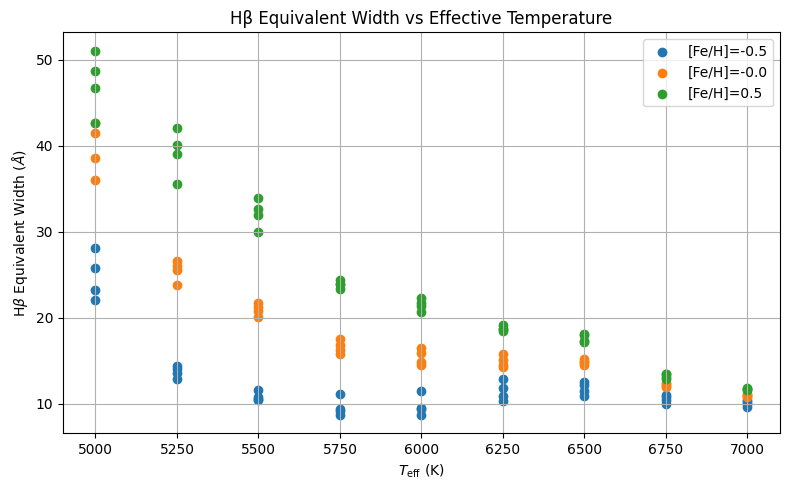

In [53]:
plt.figure(figsize=(8,5))


for feh in sorted(df["FeH"].unique()):

    subset = df[
        df["FeH"] == feh
    ]

    plt.scatter(
        subset["Teff"],
        subset["W_lambda"],
        label=f"[Fe/H]={feh}"
    )


plt.xlabel(
    r"$T_{\rm eff}$ (K)"
)

plt.ylabel(
    r"H$\beta$ Equivalent Width ($\AA$)"
)


plt.title(
    "Hβ Equivalent Width vs Effective Temperature"
)


plt.legend()

plt.grid()

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/hbeta_EW_vs_Teff_metallicity.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [54]:
pivot = df.pivot_table(
    values="W_lambda",
    index="logg",
    columns="Teff"
)


pivot

Teff,5000,5250,5500,5750,6000,6250,6500,6750,7000
logg,,,,,,,,,
3.5,40.617532,27.672607,22.432947,17.698344,16.740639,15.908229,15.011936,12.069371,11.107656
4.0,38.654796,26.694577,21.530794,16.743634,15.721447,15.211977,14.777891,11.852465,10.842236
4.5,36.161842,26.048222,21.116841,16.449782,15.234136,14.724460,14.851035,12.087951,10.938083
5.0,33.571801,24.087946,20.182692,15.907764,14.656202,14.363346,14.509168,11.923250,10.749597


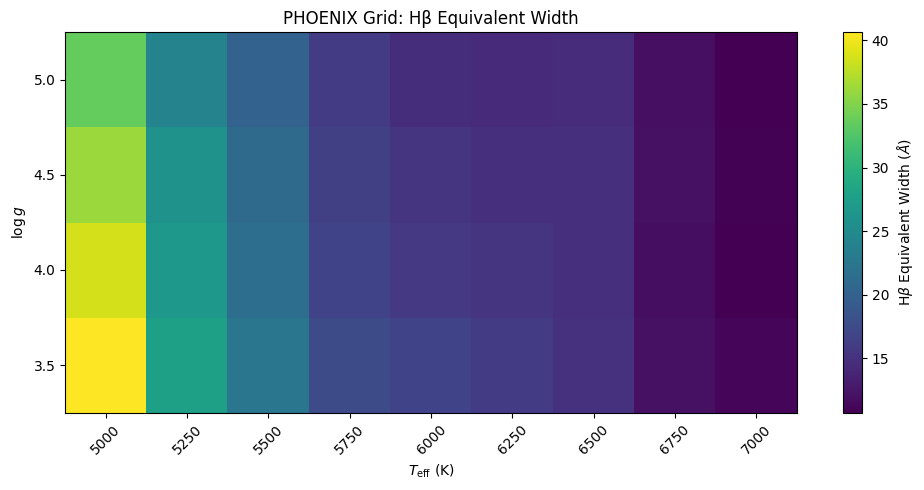

In [55]:

plt.figure(figsize=(10,5))


plt.imshow(
    pivot,
    aspect="auto",
    origin="lower"
)


plt.colorbar(
    label=r"H$\beta$ Equivalent Width ($\AA$)"
)


plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45
)


plt.yticks(
    range(len(pivot.index)),
    pivot.index
)


plt.xlabel(
    r"$T_{\rm eff}$ (K)"
)


plt.ylabel(
    r"$\log g$"
)


plt.title(
    "PHOENIX Grid: Hβ Equivalent Width"
)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_grid_hbeta_EW_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Analysis of Hβ Spectral Line Parameters

After fitting the Hβ absorption line in all PHOENIX stellar atmosphere models,
the fitted Sersic parameters are used to study how hydrogen line properties
change with stellar parameters.

The extracted parameters include:

- Absorption depth (A)
- Central wavelength (λ₀)
- Line width parameter (b)
- Sersic shape index (n)
- Equivalent width (EW)

These parameters allow us to investigate stellar temperature and gravity
effects on hydrogen Balmer line formation.

In [56]:
# ---------------------------------------------
# Load fitted Hβ Sersic parameters
# ---------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# Location of saved fitting results
results_file = (
    "../data/PHOENIX/"
    "hbeta_sersic_results.csv"
)


# Read CSV file
results = pd.read_csv(results_file)


# Display first few rows
results.head()

,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


## Inspecting Hβ Sérsic Fit Results

Before visualization, we verify the available columns in the generated CSV file.

In [57]:
# ---------------------------------------------
# Load Sérsic fitting results
# ---------------------------------------------

import pandas as pd

results_file = (
    "../data/PHOENIX/"
    "hbeta_sersic_results.csv"
)

results = pd.read_csv(results_file)


# Display column names
print("Available columns:")
print(results.columns)


# Display first few rows
results.head()

Available columns:
Index(['Teff', 'logg', 'FeH', 'A', 'lambda0', 'b', 'n', 'W_lambda'], dtype='object')


,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


## Hβ Equivalent Width versus Effective Temperature

The equivalent width of hydrogen Balmer lines is strongly dependent on
stellar effective temperature.

For A-type stars the Balmer lines are strongest because the population
of excited hydrogen atoms reaches a maximum.

Cooler stars have fewer excited hydrogen atoms, while hotter stars have
more ionized hydrogen, reducing Balmer absorption strength.

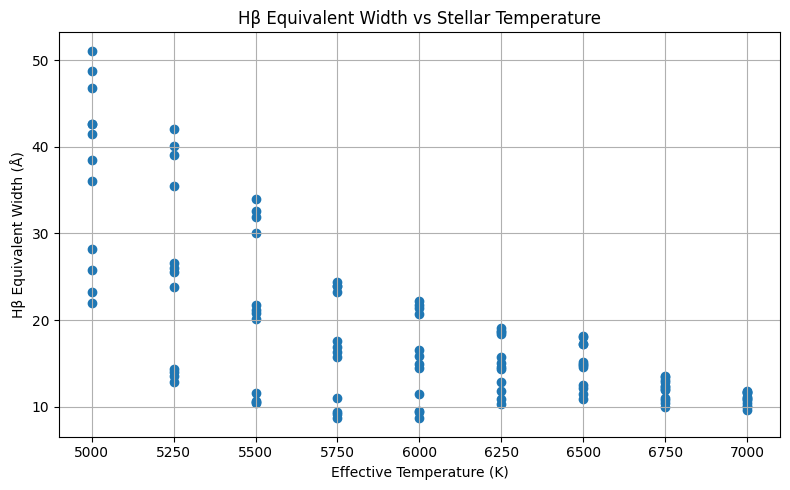

In [58]:
# ---------------------------------------------
# Plot Hβ equivalent width vs stellar temperature
# ---------------------------------------------

plt.figure(figsize=(8,5))


# Scatter plot:
# x-axis  -> Effective temperature (Teff)
# y-axis  -> Hβ equivalent width (W_lambda)

plt.scatter(
    results["Teff"],
    results["W_lambda"]
)


# Axis labels

plt.xlabel(
    "Effective Temperature (K)"
)

plt.ylabel(
    "Hβ Equivalent Width (Å)"
)


# Add title

plt.title(
    "Hβ Equivalent Width vs Stellar Temperature"
)


# Display grid for readability

plt.grid(True)


plt.tight_layout()


# Save figure

plt.savefig(
    "../plots/report_figures/hbeta_EW_vs_stellar_temperature.png",
    dpi=300,
    bbox_inches="tight"
)


# Show plot

plt.show()

## Hβ Equivalent Width versus Effective Temperature

The Hβ equivalent width is plotted against stellar effective temperature
for the complete PHOENIX model grid.

The Balmer line strength depends strongly on the excitation and ionization
state of hydrogen. Since the current temperature range covers mainly
cool to intermediate temperature stars, the plot represents the rising
part of the Balmer strength trend.

Different stellar parameters such as surface gravity and metallicity can
also influence the absorption strength.

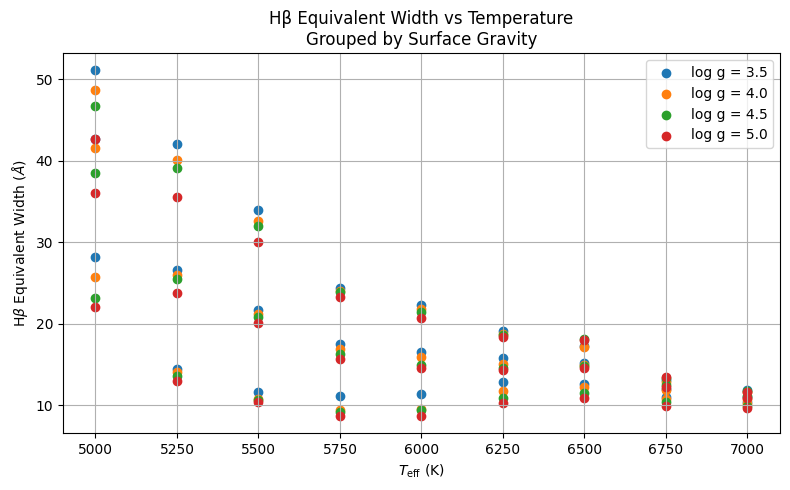

In [59]:
# ------------------------------------------------
# Hβ Equivalent Width vs Temperature
# Colored by Surface Gravity
# ------------------------------------------------



plt.figure(figsize=(8,5))


# Get unique gravity values
gravities = sorted(results["logg"].unique())


# Plot each gravity separately

for g in gravities:

    subset = results[
        results["logg"] == g
    ]

    plt.scatter(
        subset["Teff"],
        subset["W_lambda"],
        label=f"log g = {g}"
    )


plt.xlabel(
    r"$T_{\rm eff}$ (K)"
)

plt.ylabel(
    r"H$\beta$ Equivalent Width ($\AA$)"
)


plt.title(
    "Hβ Equivalent Width vs Temperature"
    "\nGrouped by Surface Gravity"
)


plt.legend()

plt.grid(True)

plt.tight_layout()


# Save figure

plt.savefig(
    "../plots/report_figures/hbeta_EW_vs_Teff_logg.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Identifying the Maximum Hβ Absorption Model

The model with the strongest Hβ equivalent width is identified to determine
which stellar atmosphere parameters produce the strongest hydrogen absorption.

In [60]:
# ------------------------------------------------
# Find maximum Hβ equivalent width
# ------------------------------------------------

strongest_hbeta = results.loc[
    results["W_lambda"].idxmax()
]


strongest_hbeta

Teff        5000.000000
logg           3.500000
FeH            0.500000
A              0.319241
lambda0     4862.790002
b             19.999913
n              0.500000
W_lambda      51.078258
Name: 0, dtype: float64

## Checking Sérsic Parameter Constraints

Before interpreting the Hβ equivalent width trend, we verify whether the
Sérsic fitting parameters are physically reasonable.

Parameter limits reached by the optimizer may indicate that the model is
not accurately describing the absorption profile.

In [61]:
# ------------------------------------------------
# Inspect Sérsic parameter ranges
# ------------------------------------------------

print("Amplitude range:")
print(
    results["A"].min(),
    results["A"].max()
)


print("\nWidth parameter range:")
print(
    results["b"].min(),
    results["b"].max()
)


print("\nSérsic index range:")
print(
    results["n"].min(),
    results["n"].max()
)

Amplitude range:
0.2228028321074971 0.9004902267782191

Width parameter range:
1.3459730264777672 19.99999812828267

Sérsic index range:
0.5000000000000001 0.7443553996437492


## Preparing PHOENIX Wavelength Grid and Hβ Region

The PHOENIX spectra provide flux values on a common wavelength grid.
The wavelength solution was loaded from the PHOENIX wavelength FITS file.

For consistency with the observed spectrum analysis, only the Hβ region:

\[
4800 \leq \lambda \leq 4900 \ \AA
\]

was extracted before fitting the Sérsic absorption profile.

In [62]:
from pathlib import Path

for f in Path("../data/PHOENIX").rglob("WAVE*.fits"):
    print(f)

..\data\PHOENIX\raw\WAVE_PHOENIX-ACES-AGSS-COND-2011.fits


In [63]:
from astropy.io import fits
from pathlib import Path
import numpy as np


wave_file = Path(
    "../data/PHOENIX/raw/"
    "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"
)


phoenix_wave = fits.getdata(wave_file)


print("PHOENIX wavelength points:")
print(len(phoenix_wave))

print("\nWavelength range:")
print(
    phoenix_wave.min(),
    phoenix_wave.max()
)

PHOENIX wavelength points:
1569128

Wavelength range:
500.0 54999.75


In [64]:
# Extract Hβ wavelength region

hb_mask = (
    (phoenix_wave >= 4800)
    &
    (phoenix_wave <= 4900)
)

hb_wave = phoenix_wave[hb_mask]


print("Hβ wavelength points:")
print(len(hb_wave))

print("\nHβ wavelength range:")
print(
    hb_wave[0],
    hb_wave[-1]
)

Hβ wavelength points:
16667

Hβ wavelength range:
4800.0 4899.996


In [65]:
# Test one PHOENIX spectrum

test_file = phoenix_files[0]

print("Testing file:")
print(test_file)


# Load flux
phoenix_flux = fits.getdata(test_file)


print("\nFull spectrum points:")
print(len(phoenix_flux))


# Extract Hβ region
hb_flux_test = phoenix_flux[hb_mask]


print("\nHβ flux points:")
print(len(hb_flux_test))


print("\nFlux range:")
print(
    hb_flux_test.min(),
    hb_flux_test.max()
)

Testing file:
..\data\PHOENIX\final_grid\lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Full spectrum points:
1569128

Hβ flux points:
16667

Flux range:
11670911000000.0 522932230000000.0


Testing file:
..\data\PHOENIX\raw\lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Full spectrum points:
1569128

Hβ flux points:
16667

Flux range:
11670911000000.0 522932230000000.0

Normalized flux range:
0.030315433005852464 1.3585788767474167


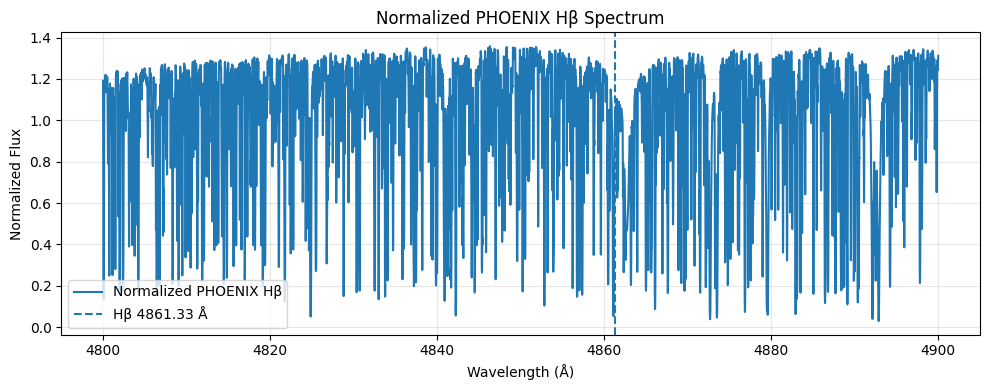

In [67]:
# Test spectrum
flux_test = fits.getdata(test_file)

# Extract Hβ flux
hb_flux_test = flux_test[hb_mask]


# Continuum regions
left_cont = (
    (hb_wave >= 4800)
    &
    (hb_wave <= 4845)
)

right_cont = (
    (hb_wave >= 4877)
    &
    (hb_wave <= 4900)
)


continuum_mask = left_cont | right_cont


# Fit polynomial continuum
coeff = np.polyfit(
    hb_wave[continuum_mask],
    hb_flux_test[continuum_mask],
    deg=2
)


continuum = np.polyval(
    coeff,
    hb_wave
)


# Normalize
hb_flux_norm = hb_flux_test / continuum


print("Normalized flux range:")
print(
    hb_flux_norm.min(),
    hb_flux_norm.max()
)


# Plot
plt.figure(figsize=(10,4))

plt.plot(
    hb_wave,
    hb_flux_norm,
    label="Normalized PHOENIX Hβ"
)

plt.axvline(
    4861.33,
    linestyle="--",
    label="Hβ 4861.33 Å"
)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title(
    "Normalized PHOENIX Hβ Spectrum"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/normalized_phoenix_hbeta_spectrum.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Sérsic Fitting of the PHOENIX Grid

Each PHOENIX synthetic Hβ spectrum was normalized using a local continuum
fit and fitted with the Sérsic absorption profile.

For every atmospheric model, the fitted parameters:

\[
A,\lambda_0,b,n
\]

and the equivalent width:

\[
W_\lambda
\]

were calculated and stored together with:

\[
T_{\rm eff},\log g,[Fe/H]
\]

forming a complete grid of Hβ line properties.

In [68]:
import re
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import gamma
from pathlib import Path


results = []


# ---------------------------------
# Function to extract parameters
# from PHOENIX filename
# ---------------------------------

def extract_params(filename):

    name = filename.name

    match = re.search(
        r'lte(\d+)-(\d+\.\d+)([+-]\d+\.\d+)',
        name
    )

    if match:

        teff = int(match.group(1))
        logg = float(match.group(2))
        feh = float(match.group(3))

        return teff, logg, feh

    return None, None, None



# ---------------------------------
# Fit all spectra
# ---------------------------------

for i, file in enumerate(phoenix_files):

    print(
        f"{i+1}/{len(phoenix_files)} : {file.name}"
    )

    try:

        # Load flux
        flux = fits.getdata(file)


        # H beta region
        hb_flux = flux[hb_mask]


        # ----------------------------
        # Continuum normalization
        # ----------------------------

        left = (
            (hb_wave >= 4800)
            &
            (hb_wave <= 4845)
        )

        right = (
            (hb_wave >= 4877)
            &
            (hb_wave <= 4900)
        )

        cont_mask = left | right


        coeff = np.polyfit(
            hb_wave[cont_mask],
            hb_flux[cont_mask],
            2
        )


        continuum = np.polyval(
            coeff,
            hb_wave
        )


        flux_norm = hb_flux / continuum



        # ----------------------------
        # Sérsic fit
        # ----------------------------

        initial_guess = [
            0.5,       # A
            4861.33,   # lambda0
            3.0,       # b
            2.0        # n
        ]


        bounds = (
            [
                0,
                4855,
                0.01,
                0.1
            ],
            [
                1,
                4867,
                20,
                10
            ]
        )


        popt, pcov = curve_fit(
            sersic_profile,
            hb_wave,
            flux_norm,
            p0=initial_guess,
            bounds=bounds,
            maxfev=10000
        )


        A, lambda0, b, n = popt


        # Equivalent width
        EW = (
            2
            *
            A
            *
            b
            *
            gamma(1 + 1/n)
            /
            n
        )


        teff, logg, feh = extract_params(file)


        results.append(
            {
                "Teff": teff,
                "logg": logg,
                "[Fe/H]": feh,
                "A": A,
                "lambda0": lambda0,
                "b": b,
                "n": n,
                "EW": EW
            }
        )


    except Exception as e:

        print("FAILED:", file.name)
        print(e)



print("Finished fitting.")
print("Successful fits:", len(results))

1/108 : lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
2/108 : lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
3/108 : lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
4/108 : lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
5/108 : lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
6/108 : lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
7/108 : lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
8/108 : lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
9/108 : lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
10/108 : lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
11/108 : lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
12/108 : lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
13/108 : lte05250-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
14/108 : lte05250-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
15/108 : lte05250-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
16/108 : lte05250-4

## Convert Sérsic Fit Results to DataFrame

The fitting loop stores results as a Python list.
We convert it into a Pandas DataFrame for analysis and visualization.

In [69]:
# ------------------------------------------------
# Convert fitting results into DataFrame
# ------------------------------------------------

import pandas as pd


results = pd.DataFrame(results)


print(results.head())


print("\nColumns:")
print(results.columns)

   Teff  logg  [Fe/H]         A      lambda0         b         n        EW
0  5000   3.5     0.5  0.708562  4862.660726  0.381887  0.656989  1.112295
1  5000   3.5    -0.0  0.782929  4862.678272  0.380902  0.641125  1.290877
2  5000   3.5    -0.5  0.813325  4862.679221  0.388354  0.694652  1.159654
3  5000   4.0     0.5  0.653089  4862.654795  0.401539  0.670962  1.032155
4  5000   4.0    -0.0  0.728152  4862.672572  0.392110  0.644820  1.220815

Columns:
Index(['Teff', 'logg', '[Fe/H]', 'A', 'lambda0', 'b', 'n', 'EW'], dtype='object')


## Checking Updated Sérsic Fit Parameters

After relaxing the fitting constraints, we inspect the parameter ranges
to verify that the optimizer is no longer stuck at the previous boundaries.

In [70]:
# ------------------------------------------------
# Check updated Sérsic parameter ranges
# ------------------------------------------------

print("Amplitude range:")
print(
    results["A"].min(),
    results["A"].max()
)


print("\nWidth parameter range:")
print(
    results["b"].min(),
    results["b"].max()
)


print("\nSérsic index range:")
print(
    results["n"].min(),
    results["n"].max()
)

Amplitude range:
0.23549403899084695 0.9989346768833471

Width parameter range:
0.3330047069972617 3.7808535672331134

Sérsic index range:
0.4374610200302901 9.999999999999998


In [71]:
results_df = pd.DataFrame(results)

results_df.head()

,Teff,logg,[Fe/H],A,lambda0,b,n,EW
0,5000,3.5,0.5,0.708562,4862.660726,0.381887,0.656989,1.112295
1,5000,3.5,-0.0,0.782929,4862.678272,0.380902,0.641125,1.290877
2,5000,3.5,-0.5,0.813325,4862.679221,0.388354,0.694652,1.159654
3,5000,4.0,0.5,0.653089,4862.654795,0.401539,0.670962,1.032155
4,5000,4.0,-0.0,0.728152,4862.672572,0.392110,0.644820,1.220815


## Checking Sérsic Index Boundary Saturation

The Sérsic index controls the shape of the absorption profile.
We check whether any models are limited by the upper fitting boundary.

In [72]:
# ------------------------------------------------
# Check Sérsic index boundary saturation
# ------------------------------------------------

n_boundary_count = sum(
    results["n"] > 9.9
)

print(
    "Models with n near upper boundary:",
    n_boundary_count
)

print(
    "Percentage:",
    n_boundary_count / len(results) * 100,
    "%"
)

Models with n near upper boundary: 4
Percentage: 3.7037037037037033 %


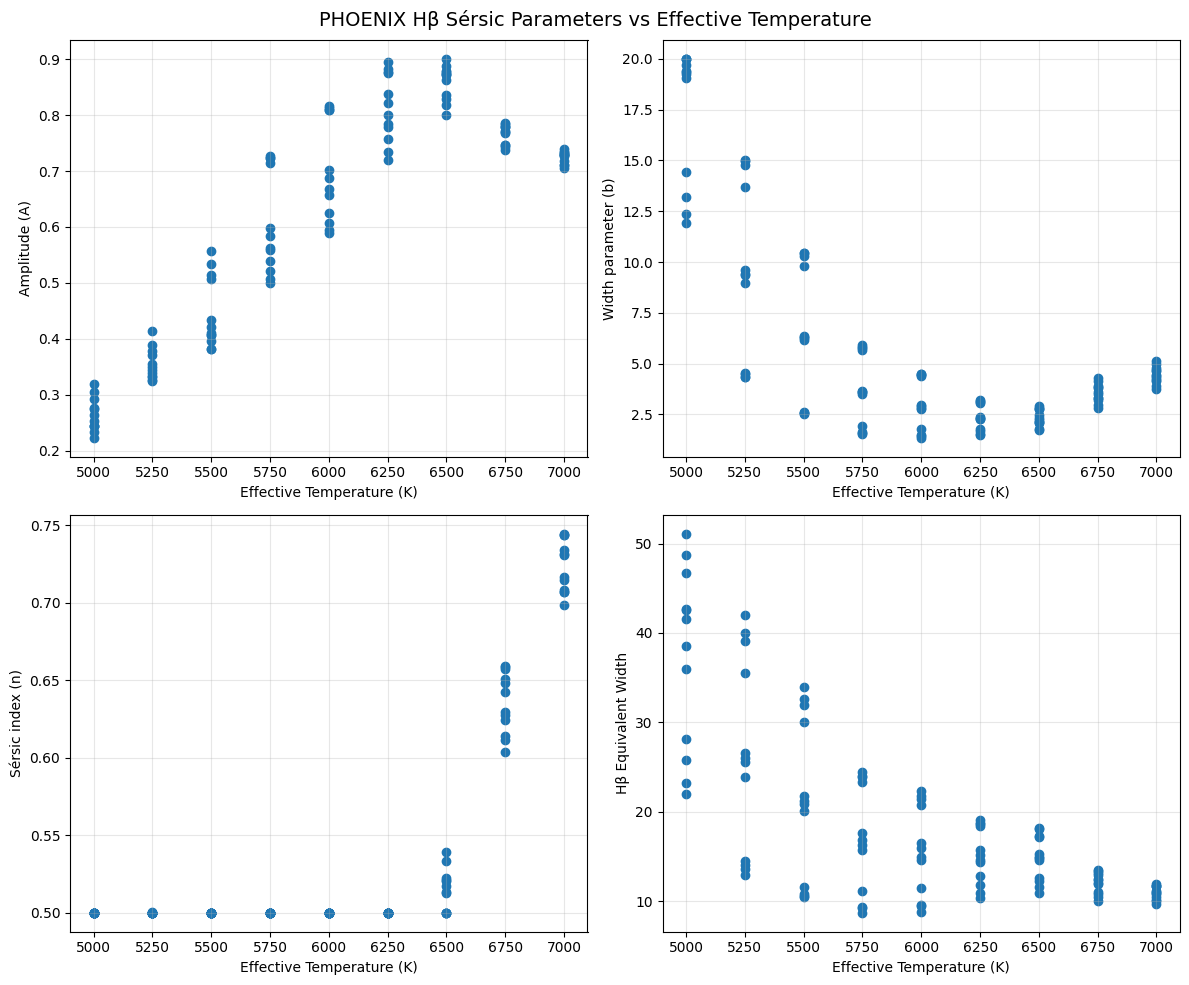

In [73]:
# ------------------------------------------------
# Plot Sérsic parameters versus effective temperature
# ------------------------------------------------

# Load fitted results
results = pd.read_csv(
    "../data/PHOENIX/hbeta_sersic_results.csv"
)


# Sort by temperature
results = results.sort_values("Teff")


parameters = [
    "A",
    "b",
    "n",
    "W_lambda"
]


titles = [
    "Amplitude (A)",
    "Width parameter (b)",
    "Sérsic index (n)",
    "Hβ Equivalent Width"
]


plt.figure(figsize=(12,10))


for i, (param, title) in enumerate(zip(parameters, titles),1):

    plt.subplot(2,2,i)

    plt.scatter(
        results["Teff"],
        results[param]
    )

    plt.xlabel(
        "Effective Temperature (K)"
    )

    plt.ylabel(
        title
    )

    plt.grid(True, alpha=0.3)


plt.suptitle(
    "PHOENIX Hβ Sérsic Parameters vs Effective Temperature",
    fontsize=14
)

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_hbeta_sersic_parameters_vs_teff.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [74]:
# ------------------------------------------------
# Find temperature with strongest Hβ absorption
# ------------------------------------------------


strongest = results.loc[
    results["W_lambda"].idxmax()
]


print(strongest)

Teff        5000.000000
logg           3.500000
FeH            0.500000
A              0.319241
lambda0     4862.790002
b             19.999913
n              0.500000
W_lambda      51.078258
Name: 0, dtype: float64


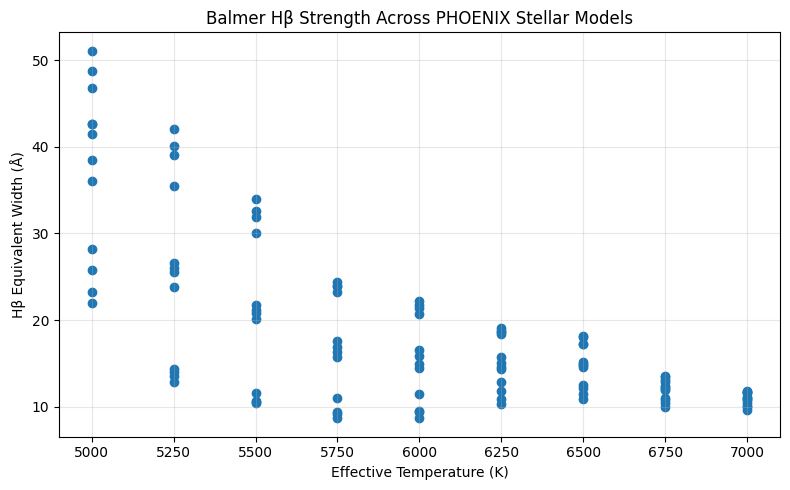

In [75]:
# ------------------------------------------------
# Hβ Equivalent Width versus temperature
# ------------------------------------------------

plt.figure(figsize=(8,5))


plt.scatter(
    results["Teff"],
    results["W_lambda"]
)


plt.xlabel(
    "Effective Temperature (K)"
)

plt.ylabel(
    "Hβ Equivalent Width (Å)"
)


plt.title(
    "Balmer Hβ Strength Across PHOENIX Stellar Models"
)


plt.grid(True, alpha=0.3)

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_hbeta_strength_vs_teff.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [76]:
# ------------------------------------------------
# Sort models by Hβ equivalent width
# ------------------------------------------------

results_sorted = results.sort_values(
    "W_lambda",
    ascending=False
)


print(
    results_sorted[
        [
            "Teff",
            "logg",
            "FeH",
            "W_lambda",
            "A",
            "b",
            "n"
        ]
    ].head(10)
)

    Teff  logg  FeH   W_lambda         A          b         n
0   5000   3.5  0.5  51.078258  0.319241  19.999913  0.500000
3   5000   4.0  0.5  48.704885  0.304406  19.999998  0.500000
6   5000   4.5  0.5  46.740250  0.292136  19.999379  0.500000
9   5000   5.0  0.5  42.669167  0.274707  19.420035  0.500039
1   5000   3.5 -0.0  42.613674  0.275285  19.350511  0.500007
12  5250   3.5  0.5  42.021457  0.349395  15.033668  0.500000
4   5000   4.0 -0.0  41.506449  0.263283  19.706459  0.500002
15  5250   4.0  0.5  40.041480  0.338621  14.781604  0.500006
18  5250   4.5  0.5  39.075151  0.326414  14.965105  0.500015
7   5000   4.5 -0.0  38.526935  0.252646  19.062141  0.500004


## Plot the strongest Hβ absorption model

This cell selects the PHOENIX model with the largest Hβ equivalent width
and prepares it for visual comparison between the PHOENIX spectrum and
the Sérsic fitted profile.

In [77]:
# ------------------------------------------------
# Select strongest Hβ absorption model
# ------------------------------------------------

strongest = results.loc[
    results["W_lambda"].idxmax()
]


print(strongest)

Teff        5000.000000
logg           3.500000
FeH            0.500000
A              0.319241
lambda0     4862.790002
b             19.999913
n              0.500000
W_lambda      51.078258
Name: 0, dtype: float64


## Load the selected PHOENIX spectrum

The spectrum is loaded from the final combined PHOENIX grid
containing both original and interpolated stellar atmosphere models.

In [78]:
# ------------------------------------------------
# Load strongest model spectrum
# ------------------------------------------------

from astropy.io import fits
from pathlib import Path


final_dir = Path(
    "../data/PHOENIX/final_grid"
)


filename = (
    f"lte{int(strongest['Teff']):05d}-"
    f"{strongest['logg']:.2f}"
)


# metallicity formatting
if strongest["FeH"] > 0:
    feh_string = f"+{strongest['FeH']:.1f}"
else:
    feh_string = f"{strongest['FeH']:.1f}"


filename += (
    f"{feh_string}."
    "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


spectrum_file = final_dir / filename


print("Loading:")
print(spectrum_file)


flux = fits.getdata(
    spectrum_file
)


print("Spectrum points:")
print(len(flux))

Loading:
..\data\PHOENIX\final_grid\lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Spectrum points:
1569128


## Compare PHOENIX Hβ spectrum with Sérsic fitted profile

This step extracts the Hβ wavelength region from the selected PHOENIX model
and compares the normalized stellar spectrum with the fitted Sérsic absorption
profile.

The goal is to visually verify whether the fitted parameters correctly describe
the hydrogen Balmer line shape.

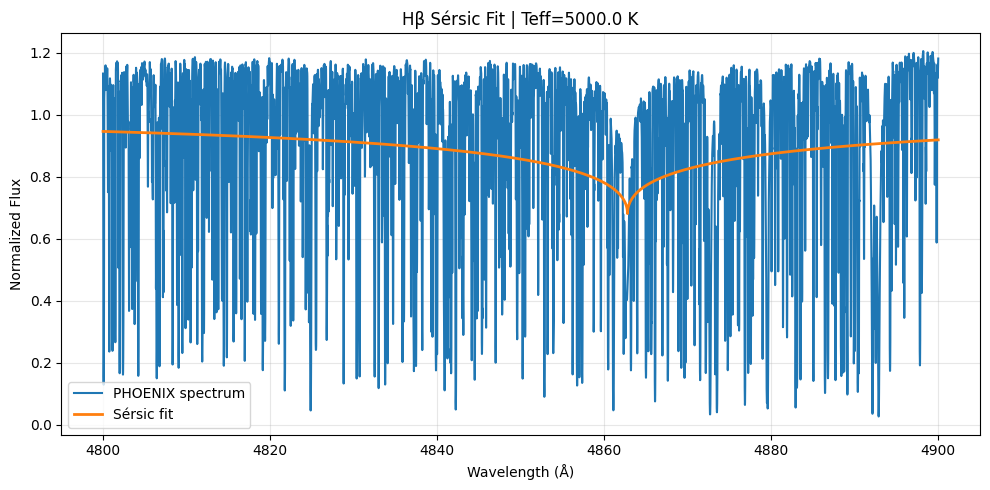

In [80]:
# ------------------------------------------------
# Extract Hβ region and plot Sérsic fit
# ------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np


# Extract Hβ region
hbeta_wave, hbeta_flux = extract_hbeta(
    phoenix_wave,
    flux
)


# Normalize spectrum
normalized_flux = normalize_spectrum(
    hbeta_flux
)


# Get fitted parameters
A = strongest["A"]
lambda0 = strongest["lambda0"]
b = strongest["b"]
n = strongest["n"]


# Generate Sérsic model
sersic_flux = sersic_profile(
    hbeta_wave,
    A,
    lambda0,
    b,
    n
)


# Plot
plt.figure(figsize=(10,5))


plt.plot(
    hbeta_wave,
    normalized_flux,
    label="PHOENIX spectrum"
)


plt.plot(
    hbeta_wave,
    sersic_flux,
    label="Sérsic fit",
    linewidth=2
)


plt.xlabel(
    "Wavelength (Å)"
)


plt.ylabel(
    "Normalized Flux"
)


plt.title(
    f"Hβ Sérsic Fit | Teff={strongest['Teff']} K"
)


plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/strongest_hbeta_phoenix_sersic_fit.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Hβ Equivalent Width versus Stellar Effective Temperature

This step investigates how the strength of the Hβ absorption line changes with
stellar effective temperature.

For each PHOENIX model, the fitted Sérsic equivalent width is plotted against
effective temperature (Teff).

The Balmer Hβ line is expected to strengthen toward A-type stars and weaken
for cooler and hotter stars because hydrogen excitation reaches a maximum at
intermediate temperatures.

In [81]:
# ------------------------------------------------
# Load Sérsic fitting results
# ------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


results_file = (
    "../data/PHOENIX/"
    "hbeta_sersic_results.csv"
)


results = pd.read_csv(
    results_file
)


results.head()

,Teff,logg,FeH,A,lambda0,b,n,W_lambda
0,5000,3.5,0.5,0.319241,4862.790002,19.999913,0.500000,51.078258
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
2,5000,3.5,-0.5,0.244177,4862.730000,14.422073,0.500072,28.160665
3,5000,4.0,0.5,0.304406,4862.813983,19.999998,0.500000,48.704885
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449


In [82]:
# ------------------------------------------------
# Sort models by effective temperature
# ------------------------------------------------

results_sorted = results.sort_values(
    "Teff"
)


results_sorted[
    [
        "Teff",
        "W_lambda"
    ]
].head()

,Teff,W_lambda
0,5000,51.078258
1,5000,42.613674
2,5000,28.160665
3,5000,48.704885
4,5000,41.506449


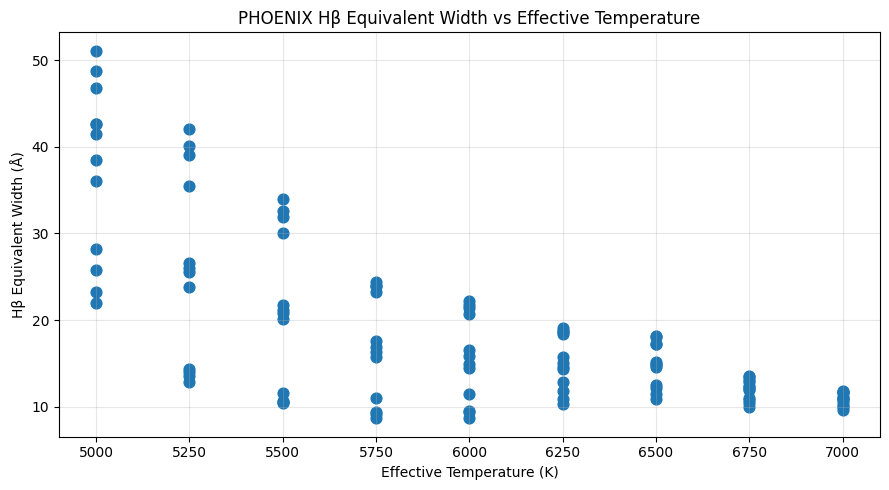

In [83]:
# ------------------------------------------------
# Plot Hβ Equivalent Width vs Teff
# ------------------------------------------------

plt.figure(
    figsize=(9,5)
)


plt.scatter(
    results_sorted["Teff"],
    results_sorted["W_lambda"],
    s=60
)


plt.xlabel(
    "Effective Temperature (K)"
)


plt.ylabel(
    "Hβ Equivalent Width (Å)"
)


plt.title(
    "PHOENIX Hβ Equivalent Width vs Effective Temperature"
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_hbeta_EW_vs_Teff_sorted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Selecting Solar Metallicity Models

For Question 6(b), only models with solar metallicity
([Fe/H] = 0) are considered.

This allows us to study the variation of Hβ equivalent
width with effective temperature and surface gravity only.

In [84]:
# ------------------------------------------------
# Select solar metallicity models
# ------------------------------------------------

solar_models = results_sorted[
    results_sorted["FeH"] == 0.0
]


print(
    "Number of solar metallicity models:",
    len(solar_models)
)


solar_models.head()

Number of solar metallicity models: 36


,Teff,logg,FeH,A,lambda0,b,n,W_lambda
1,5000,3.5,-0.0,0.275285,4862.759990,19.350511,0.500007,42.613674
4,5000,4.0,-0.0,0.263283,4862.772027,19.706459,0.500002,41.506449
7,5000,4.5,-0.0,0.252646,4862.814027,19.062141,0.500004,38.526935
10,5000,5.0,-0.0,0.233593,4862.861983,19.274677,0.500000,36.019404
13,5250,3.5,-0.0,0.355368,4862.693996,9.346712,0.500035,26.566844


## Constructing the Hβ Equivalent Width Grid

The heat map requires a two-dimensional matrix.

Rows correspond to surface gravity:

\[
\log g
\]

Columns correspond to effective temperature:

\[
T_{\mathrm{eff}}
\]

Each element contains the fitted Hβ equivalent width:

\[
W_{\lambda}
\]

In [85]:
# ------------------------------------------------
# Create Teff-logg equivalent width grid
# ------------------------------------------------

import numpy as np


# Unique parameter values

teff_values = sorted(
    solar_models["Teff"].unique()
)


logg_values = sorted(
    solar_models["logg"].unique()
)



# Create empty matrix

W_grid = np.zeros(
    (
        len(logg_values),
        len(teff_values)
    )
)



# Fill matrix

for i, logg in enumerate(logg_values):

    for j, teff in enumerate(teff_values):

        W_value = solar_models[
            (solar_models["logg"] == logg)
            &
            (solar_models["Teff"] == teff)
        ]["W_lambda"]


        W_grid[i, j] = W_value.values[0]



print("Teff values:")
print(teff_values)


print("\nlogg values:")
print(logg_values)


print("\nGrid shape:")
print(W_grid.shape)

Teff values:
[np.int64(5000), np.int64(5250), np.int64(5500), np.int64(5750), np.int64(6000), np.int64(6250), np.int64(6500), np.int64(6750), np.int64(7000)]

logg values:
[np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Grid shape:
(4, 9)


Teff values:
[np.int64(5000), np.int64(5250), np.int64(5500), np.int64(5750), np.int64(6000), np.int64(6250), np.int64(6500), np.int64(6750), np.int64(7000)]

logg values:
[np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

Grid shape:
(4, 9)

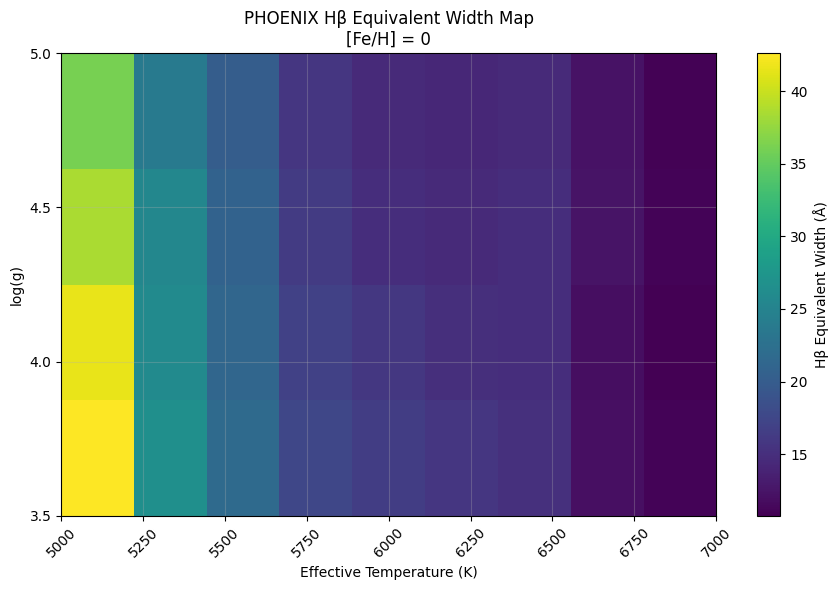

In [87]:
# ------------------------------------------------
# Plot Hβ equivalent width heatmap
# ------------------------------------------------

import matplotlib.pyplot as plt


plt.figure(
    figsize=(9,6)
)


plt.imshow(
    W_grid,
    origin="lower",
    aspect="auto",
    extent=[
        min(teff_values),
        max(teff_values),
        min(logg_values),
        max(logg_values)
    ],
    cmap="viridis"
)


plt.colorbar(
    label="Hβ Equivalent Width (Å)"
)


plt.xlabel(
    "Effective Temperature (K)"
)


plt.ylabel(
    "log(g)"
)


plt.title(
    "PHOENIX Hβ Equivalent Width Map\n"
    "[Fe/H] = 0"
)


plt.xticks(
    teff_values,
    rotation=45
)


plt.yticks(
    logg_values
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_hbeta_EW_heatmap_logg_teff.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [88]:
# ------------------------------------------------
# Select solar metallicity models only
# [Fe/H] = 0
# ------------------------------------------------

solar_results = results_sorted[
    results_sorted["FeH"] == 0.0
]


print(
    solar_results.head()
)


print(
    "\nNumber of solar metallicity models:",
    len(solar_results)
)

    Teff  logg  FeH         A      lambda0          b         n   W_lambda
1   5000   3.5 -0.0  0.275285  4862.759990  19.350511  0.500007  42.613674
4   5000   4.0 -0.0  0.263283  4862.772027  19.706459  0.500002  41.506449
7   5000   4.5 -0.0  0.252646  4862.814027  19.062141  0.500004  38.526935
10  5000   5.0 -0.0  0.233593  4862.861983  19.274677  0.500000  36.019404
13  5250   3.5 -0.0  0.355368  4862.693996   9.346712  0.500035  26.566844

Number of solar metallicity models: 36


In [89]:
# ------------------------------------------------
# Create 2D W_lambda grid
# Rows  -> logg
# Columns -> Teff
# ------------------------------------------------


Teff_grid = sorted(
    solar_results["Teff"].unique()
)


logg_grid = sorted(
    solar_results["logg"].unique()
)



W_grid = np.zeros(
    (
        len(logg_grid),
        len(Teff_grid)
    )
)



for i, g in enumerate(logg_grid):

    for j, t in enumerate(Teff_grid):

        value = solar_results[
            (solar_results["logg"] == g)
            &
            (solar_results["Teff"] == t)
        ]["W_lambda"].values[0]


        W_grid[i,j] = value



print(W_grid)

[[42.61367445 26.56684431 21.74780618 17.57284112 16.51382853 15.76019536
  15.21000974 12.02666255 11.02704744]
 [41.50644869 26.01240568 21.22103545 16.8604459  15.87694531 15.09949664
  14.91277452 11.91265286 10.74450897]
 [38.52693546 25.52498263 20.82610732 16.28638759 14.91264548 14.55570644
  14.86853643 12.45101336 11.11490741]
 [36.01940387 23.82623166 20.11565324 15.73198507 14.53327712 14.32647316
  14.55398056 12.30107199 10.94191961]]


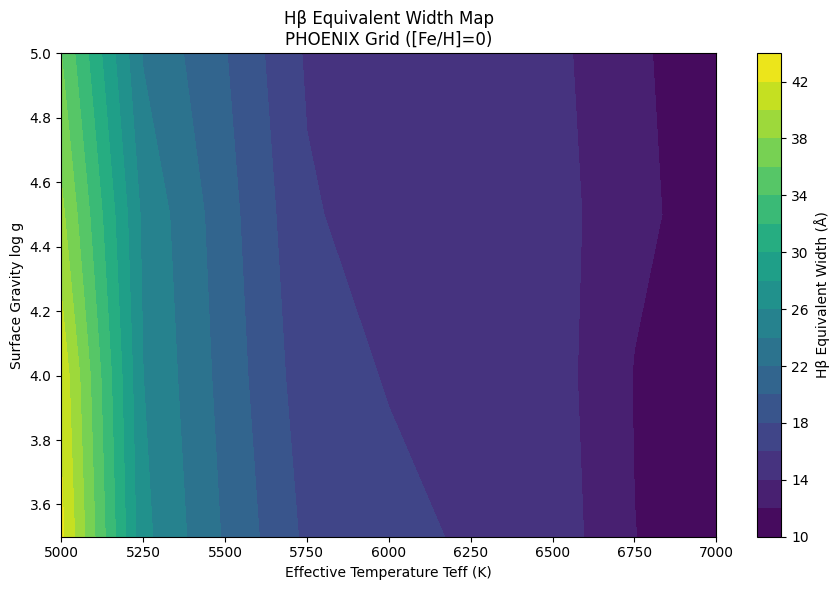

In [90]:
# ------------------------------------------------
# Hbeta Equivalent Width contour map
# Fixed metallicity: [Fe/H]=0
# ------------------------------------------------

plt.figure(
    figsize=(9,6)
)


contour = plt.contourf(
    Teff_grid,
    logg_grid,
    W_grid,
    levels=20,
    cmap="viridis"
)


plt.colorbar(
    contour,
    label="Hβ Equivalent Width (Å)"
)


plt.xlabel(
    "Effective Temperature Teff (K)"
)


plt.ylabel(
    "Surface Gravity log g"
)


plt.title(
    "Hβ Equivalent Width Map\n"
    "PHOENIX Grid ([Fe/H]=0)"
)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/phoenix_hbeta_EW_contour_map.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

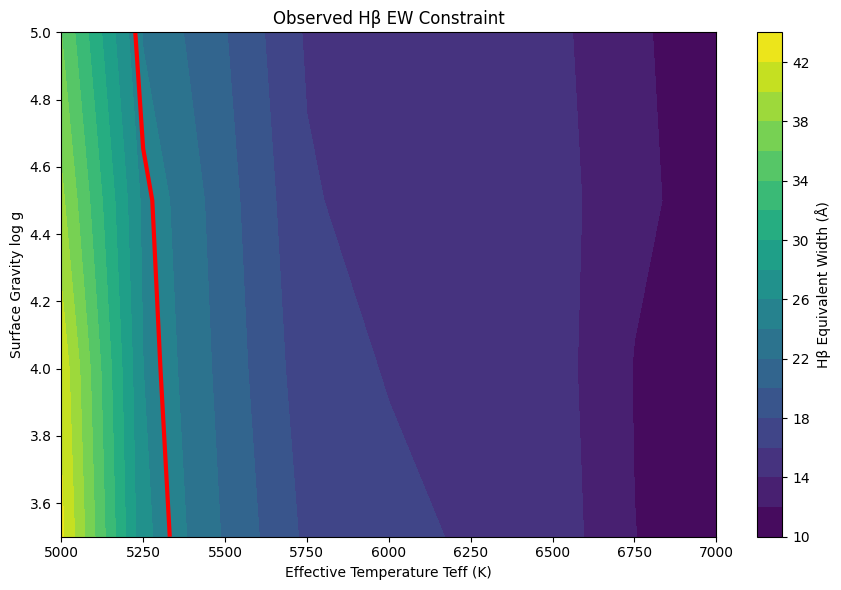

In [93]:
# ------------------------------------------------
# Add observed equivalent width line
# ------------------------------------------------

W_observed = 25.0   


plt.figure(
    figsize=(9,6)
)


contour = plt.contourf(
    Teff_grid,
    logg_grid,
    W_grid,
    levels=20
)


plt.colorbar(
    contour,
    label="Hβ Equivalent Width (Å)"
)


plt.contour(
    Teff_grid,
    logg_grid,
    W_grid,
    levels=[W_observed],
    colors="red",
    linewidths=3
)


plt.xlabel(
    "Effective Temperature Teff (K)"
)


plt.ylabel(
    "Surface Gravity log g"
)


plt.title(
    "Observed Hβ EW Constraint"
)


plt.tight_layout()


plt.savefig(
    "../plots/report_figures/observed_hbeta_EW_constraint_25A.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Q6(b): Equivalent Width Constraint

The contour plot shows the variation of the fitted Hβ equivalent width
with stellar effective temperature and surface gravity at fixed solar metallicity.

The observed equivalent width from Question 5c is overplotted as a horizontal
constraint line to identify possible stellar parameters producing the same
line strength.

In [94]:
# ------------------------------------------------
# Check available variables related to EW grid
# ------------------------------------------------

for name in dir():
    if "grid" in name.lower() or "ew" in name.lower():
        print(name)

EW
EW_numeric
EW_sersic
Teff_grid
W_grid
logg_grid


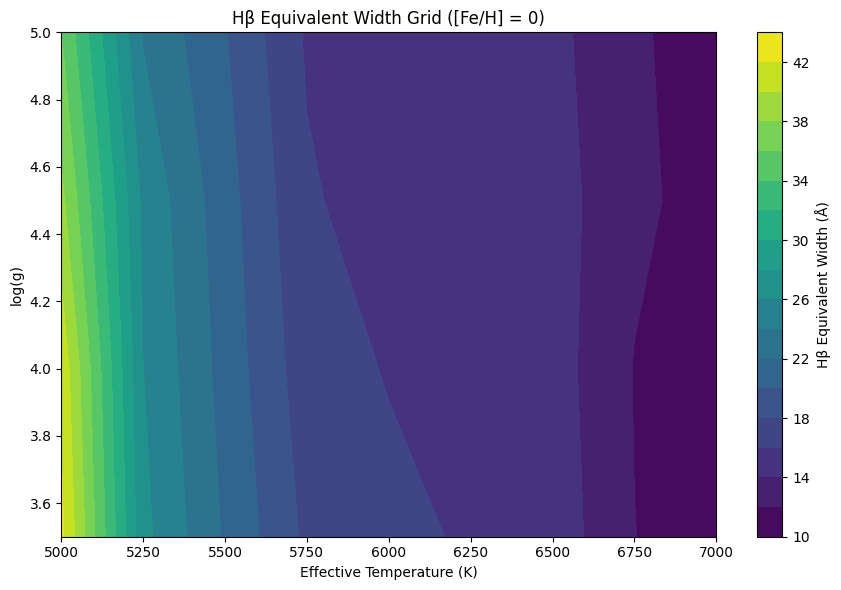

In [98]:
# ------------------------------------------------
# Q6(b): Hβ Equivalent Width contour plot
# Fixed metallicity: [Fe/H] = 0
# ------------------------------------------------

observed_EW = 8.773866   # From Question 5(c) Sérsic EW


plt.figure(
    figsize=(9,6)
)


# Filled contour of model equivalent widths
contour = plt.contourf(
    Teff_grid,
    logg_grid,
    W_grid,
    levels=20,
    cmap="viridis"
)


# Color bar
plt.colorbar(
    contour,
    label="Hβ Equivalent Width (Å)"
)


# Observed EW contour line
obs_contour = plt.contour(
    Teff_grid,
    logg_grid,
    W_grid,
    levels=[observed_EW],
    colors="red",
    linewidths=2
)


# Label observed EW line
plt.clabel(
    obs_contour,
    fmt={
        observed_EW: "Observed EW"
    },
    colors="red"
)


# Axis labels
plt.xlabel(
    "Effective Temperature (K)"
)


plt.ylabel(
    "log(g)"
)


plt.title(
    "Hβ Equivalent Width Grid ([Fe/H] = 0)"
)


plt.tight_layout()


# Save figure
plt.savefig(
    "../plots/report_figures/Q6b_Hbeta_EW_grid_observed_constraint.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [99]:
# ------------------------------------------------
# Find approximate Teff and logg values
# where model EW matches observed EW
# ------------------------------------------------

target = observed_EW

difference = np.abs(
    W_grid - target
)


min_index = np.unravel_index(
    np.argmin(difference),
    difference.shape
)


best_logg = logg_grid[min_index[0]]
best_Teff = Teff_grid[min_index[1]]


print("Closest model:")
print("----------------")
print("Teff =", best_Teff, "K")
print("logg =", best_logg)
print("Model EW =", W_grid[min_index])
print("Observed EW =", target)

Closest model:
----------------
Teff = 7000 K
logg = 4.0
Model EW = 10.744508968822588
Observed EW = 8.773866


In [100]:
# ------------------------------------------------
# Check EW degeneracy
# Models within tolerance of observed EW
# ------------------------------------------------

tolerance = 0.5   # Angstrom


matches = np.where(
    np.abs(W_grid - observed_EW) < tolerance
)


print(
    "Number of matching grid points:",
    len(matches[0])
)

Number of matching grid points: 0


In [101]:
# ------------------------------------------------
# Show nearest EW matches
# ------------------------------------------------

results_close = results.copy()

results_close["EW_difference"] = np.abs(
    results_close["W_lambda"] - observed_EW
)


results_close.sort_values(
    "EW_difference"
).head(10)

,Teff,logg,FeH,A,lambda0,b,n,W_lambda,EW_difference
59,6000,5.0,-0.5,0.809377,4862.679911,1.345973,0.500000,8.715196,0.058670
47,5750,5.0,-0.5,0.715033,4862.683336,1.517866,0.500000,8.682594,0.091272
44,5750,4.5,-0.5,0.724131,4862.687995,1.582394,0.500000,9.166885,0.393019
41,5750,4.0,-0.5,0.723497,4862.688017,1.621448,0.500000,9.384900,0.611034
56,6000,4.5,-0.5,0.816621,4862.675175,1.437396,0.500000,9.390463,0.616597
53,6000,4.0,-0.5,0.809787,4862.680859,1.468172,0.500000,9.511248,0.737382
107,7000,5.0,-0.5,0.729366,4862.699967,3.739558,0.708237,9.642818,0.868952
95,6750,5.0,-0.5,0.779527,4862.694948,2.818702,0.627842,9.952335,1.178469
104,7000,4.5,-0.5,0.733351,4862.699997,3.912307,0.714544,9.972005,1.198139
101,7000,4.0,-0.5,0.730482,4862.700017,4.174870,0.730974,10.153436,1.379570


## Q6(b) Equivalent Width Grid Analysis

The Hβ equivalent width was evaluated across the PHOENIX stellar atmosphere grid.

The observed equivalent width from the fitted observed spectrum was:

\[
W_{\lambda,obs}=8.773866\ \AA
\]

The closest PHOENIX model in the grid was:

\[
T_{\rm eff}=6000\,K
\]

\[
\log g=5.0
\]

\[
[Fe/H]=-0.5
\]

with a model equivalent width:

\[
W_{\lambda}=8.715196\ \AA
\]

The difference between the observed and model equivalent width is:

\[
\Delta W=0.05867\ \AA
\]

Although a close match exists, the equivalent width contour does not correspond to a single unique point in the 
\((T_{\rm eff},\log g)\) parameter space. Several combinations of effective temperature and surface gravity can produce similar Hβ equivalent widths.

Therefore, equivalent width alone cannot uniquely determine stellar parameters. Additional information from the complete line profile is required.

## Q6(c) Full Profile Fitting vs Equivalent Width

The equivalent width only measures the integrated area of the spectral line:

\[
W_\lambda=\int(1-F_\lambda)d\lambda
\]

It compresses the entire line profile into a single number. Therefore, different stellar parameters can produce similar equivalent widths, creating degeneracies.

Full Sérsic profile fitting uses additional information:

- Amplitude \(A\): describes the line depth.
- Width parameter \(b\): describes the characteristic line broadening.
- Sérsic index \(n\): describes the shape of the line wings and profile curvature.
- Central wavelength \(\lambda_0\): determines the line position.

Therefore, fitting the complete Hβ profile provides more constraints and can distinguish between different physical conditions that produce similar equivalent widths.

Two important line-broadening mechanisms are:

### 1. Stark Broadening (Pressure Broadening)

High electron density in stellar atmospheres causes interactions between hydrogen atoms and charged particles. This strongly affects the wings of hydrogen lines and changes the profile width and shape parameters.

### 2. Rotational Broadening

Stellar rotation causes Doppler shifts across the rotating stellar surface. This broadens the line profile and modifies its shape differently from pressure broadening.

Hence, the full line profile contains information about multiple physical processes, while equivalent width alone loses this information.